In [1]:
# %pip install tensorflow opencv-python scikit-learn matplotlib numpy jupyter
# %pip install mediapipe --upgrade --pre


In [2]:
import cv2
import numpy as np
import os
from matplotlib import pyplot as plt
import time
import mediapipe as mp

In [3]:

mp_holistic = mp.solutions.holistic # Holistic model
mp_drawing = mp.solutions.drawing_utils # Drawing utilities

In [4]:
def mediapipe_detection(image, model):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # COLOR CONVERSION BGR 2 RGB
    image.flags.writeable = False                  # Image is no longer writeable
    results = model.process(image)                 # Make prediction
    image.flags.writeable = True                   # Image is now writeable 
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR) # COLOR COVERSION RGB 2 BGR
    return image, results



In [5]:
def draw_landmarks(image, results):
    mp_drawing.draw_landmarks(image, results.face_landmarks, mp_holistic.FACEMESH_CONTOURS) # Draw face connections
    mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS) # Draw pose connections
    mp_drawing.draw_landmarks(image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS) # Draw left hand connections
    mp_drawing.draw_landmarks(image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS) # Draw right hand connections

In [6]:
def draw_styled_landmarks(image, results):
    # Face mesh is commented out to save performance
    # mp_drawing.draw_landmarks(image, results.face_landmarks, mp_holistic.FACEMESH_CONTOURS, ...)
    
    # Draw pose connections
    mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS,
                             mp_drawing.DrawingSpec(color=(80,22,10), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(80,44,121), thickness=2, circle_radius=2)) 
    
    # Draw left hand connections
    mp_drawing.draw_landmarks(image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS, 
                             mp_drawing.DrawingSpec(color=(121,22,76), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(121,44,250), thickness=2, circle_radius=2)) 
    
    # Draw right hand connections  
    mp_drawing.draw_landmarks(image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS, 
                             mp_drawing.DrawingSpec(color=(245,117,66), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(245,66,230), thickness=2, circle_radius=2))

In [7]:
mp_holistic.POSE_CONNECTIONS

frozenset({(0, 1),
           (0, 4),
           (1, 2),
           (2, 3),
           (3, 7),
           (4, 5),
           (5, 6),
           (6, 8),
           (9, 10),
           (11, 12),
           (11, 13),
           (11, 23),
           (12, 14),
           (12, 24),
           (13, 15),
           (14, 16),
           (15, 17),
           (15, 19),
           (15, 21),
           (16, 18),
           (16, 20),
           (16, 22),
           (17, 19),
           (18, 20),
           (23, 24),
           (23, 25),
           (24, 26),
           (25, 27),
           (26, 28),
           (27, 29),
           (27, 31),
           (28, 30),
           (28, 32),
           (29, 31),
           (30, 32)})

In [8]:
mp_drawing.draw_landmarks

<function mediapipe.python.solutions.drawing_utils.draw_landmarks(image: numpy.ndarray, landmark_list: mediapipe.framework.formats.landmark_pb2.NormalizedLandmarkList, connections: Optional[List[Tuple[int, int]]] = None, landmark_drawing_spec: Union[mediapipe.python.solutions.drawing_utils.DrawingSpec, Mapping[int, mediapipe.python.solutions.drawing_utils.DrawingSpec], NoneType] = DrawingSpec(color=(0, 0, 255), thickness=2, circle_radius=2), connection_drawing_spec: Union[mediapipe.python.solutions.drawing_utils.DrawingSpec, Mapping[Tuple[int, int], mediapipe.python.solutions.drawing_utils.DrawingSpec]] = DrawingSpec(color=(224, 224, 224), thickness=2, circle_radius=2), is_drawing_landmarks: bool = True)>

In [9]:
cap = cv2.VideoCapture(0)

with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
    while cap.isOpened():

        # Read feed
        ret, frame = cap.read()
        if not ret:
            break

        # Flip frame horizontally so right hand appears correctly
        frame = cv2.flip(frame, 1)

        # Make detections
        image, results = mediapipe_detection(frame, holistic)
        print(results)
        
        # Draw landmarks
        draw_styled_landmarks(image, results)

        # Show to screen
        cv2.imshow('OpenCV Feed', image)

        # Break gracefully
        if cv2.waitKey(10) & 0xFF == ord('q'):
            break
    cap.release()
    cv2.destroyAllWindows()


c:\Users\aayus\sign_language_detection\venv\lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.soluti

In [10]:

draw_landmarks(frame, results)

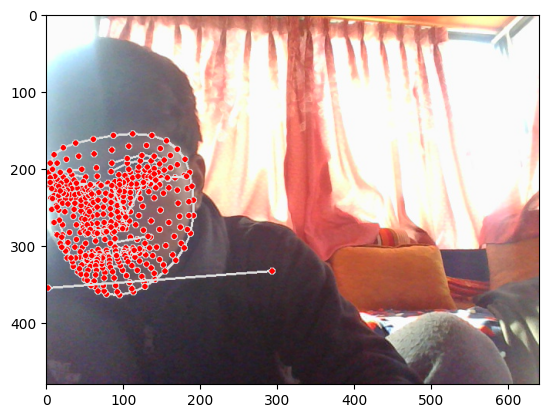

In [11]:
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

In [12]:
len(results.pose_landmarks.landmark)

33

In [13]:
pose = []
for res in results.pose_landmarks.landmark:
    test = np.array([res.x, res.y, res.z, res.visibility])
    pose.append(test)

In [14]:
pose = np.array([[res.x, res.y, res.z, res.visibility] for res in results.pose_landmarks.landmark]).flatten() if results.pose_landmarks else np.zeros(132)
face = np.array([[res.x, res.y, res.z] for res in results.face_landmarks.landmark]).flatten() if results.face_landmarks else np.zeros(1404)
lh = np.array([[res.x, res.y, res.z] for res in results.left_hand_landmarks.landmark]).flatten() if results.left_hand_landmarks else np.zeros(21*3)
rh = np.array([[res.x, res.y, res.z] for res in results.right_hand_landmarks.landmark]).flatten() if results.right_hand_landmarks else np.zeros(21*3)

In [15]:
# results.left_hand_landmarks.landmark

In [16]:
def extract_keypoints(results):
    # 1. Pose: 33 landmarks * 4 coords (x, y, z, visibility) = 132 features
    pose = np.array([[res.x, res.y, res.z, res.visibility] for res in results.pose_landmarks.landmark]).flatten() if results.pose_landmarks else np.zeros(33*4)
    
    # 2. Left Hand: 21 landmarks * 3 coords (x, y, z) = 63 features
    lh = np.array([[res.x, res.y, res.z] for res in results.left_hand_landmarks.landmark]).flatten() if results.left_hand_landmarks else np.zeros(21*3)
    
    # 3. Right Hand: 21 landmarks * 3 coords (x, y, z) = 63 features
    rh = np.array([[res.x, res.y, res.z] for res in results.right_hand_landmarks.landmark]).flatten() if results.right_hand_landmarks else np.zeros(21*3)
    
    # Total features: 132 + 63 + 63 = 258
    return np.concatenate([pose, lh, rh])

In [17]:

result_test = extract_keypoints(results)

In [18]:

result_test

array([ 1.62237480e-01,  5.48298895e-01, -1.09957683e+00,  9.99688148e-01,
        1.97582573e-01,  4.55145419e-01, -1.08094609e+00,  9.99351203e-01,
        2.22846061e-01,  4.48973000e-01, -1.08144593e+00,  9.99377608e-01,
        2.46387959e-01,  4.43628579e-01, -1.08244932e+00,  9.99427021e-01,
        1.33029953e-01,  4.63642418e-01, -1.03819919e+00,  9.99271333e-01,
        1.12138256e-01,  4.62876439e-01, -1.03671706e+00,  9.99135613e-01,
        9.00554508e-02,  4.62050736e-01, -1.03678763e+00,  9.98999238e-01,
        2.85282701e-01,  4.39561576e-01, -7.18367279e-01,  9.99514997e-01,
        6.24639392e-02,  4.58023459e-01, -4.70348924e-01,  9.99066353e-01,
        2.06669211e-01,  6.01641119e-01, -9.47790027e-01,  9.99796271e-01,
        1.30116120e-01,  6.20750606e-01, -8.82552028e-01,  9.99710262e-01,
        4.57879066e-01,  6.94460571e-01, -5.65222263e-01,  9.99801159e-01,
        4.33129910e-03,  7.40093887e-01, -1.80195924e-02,  9.98745263e-01,
        6.83110535e-01,  

In [19]:
np.save('0', result_test)

In [20]:
np.load('0.npy')

array([ 1.62237480e-01,  5.48298895e-01, -1.09957683e+00,  9.99688148e-01,
        1.97582573e-01,  4.55145419e-01, -1.08094609e+00,  9.99351203e-01,
        2.22846061e-01,  4.48973000e-01, -1.08144593e+00,  9.99377608e-01,
        2.46387959e-01,  4.43628579e-01, -1.08244932e+00,  9.99427021e-01,
        1.33029953e-01,  4.63642418e-01, -1.03819919e+00,  9.99271333e-01,
        1.12138256e-01,  4.62876439e-01, -1.03671706e+00,  9.99135613e-01,
        9.00554508e-02,  4.62050736e-01, -1.03678763e+00,  9.98999238e-01,
        2.85282701e-01,  4.39561576e-01, -7.18367279e-01,  9.99514997e-01,
        6.24639392e-02,  4.58023459e-01, -4.70348924e-01,  9.99066353e-01,
        2.06669211e-01,  6.01641119e-01, -9.47790027e-01,  9.99796271e-01,
        1.30116120e-01,  6.20750606e-01, -8.82552028e-01,  9.99710262e-01,
        4.57879066e-01,  6.94460571e-01, -5.65222263e-01,  9.99801159e-01,
        4.33129910e-03,  7.40093887e-01, -1.80195924e-02,  9.98745263e-01,
        6.83110535e-01,  

In [21]:
# Path for exported data, numpy arrays
DATA_PATH = os.path.join('MP_Data') 

# Actions that we try to detect
actions = np.array(['hello', 'thanks', 'iloveyou'])

# Thirty videos worth of data
no_sequences = 30

# Videos are going to be 30 frames in length
sequence_length = 30

# Folder start
start_folder = 1

In [22]:
# DATA_PATH = 'NumbersKeypoints'
# os.makedirs(DATA_PATH, exist_ok=True)

# DATASET_PATH = r'Sign-Language-Digits-Dataset-master\Sign-Language-Digits-Dataset-master\Dataset'

# with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
#     for label in range(0, 10):
#         folder_path = os.path.join(DATASET_PATH, str(label))
#         save_folder = os.path.join(DATA_PATH, str(label))
#         os.makedirs(save_folder, exist_ok=True)

#         if not os.path.exists(folder_path):
#             print(f"Warning: Folder {folder_path} does not exist. Skipping.")
#             continue

#         img_files = os.listdir(folder_path)
#         if not img_files:
#             print(f"Warning: Folder {folder_path} is empty. Skipping.")
#             continue

#         for idx, img_file in enumerate(img_files):
#             img_path = os.path.join(folder_path, img_file)
#             frame = cv2.imread(img_path)
#             if frame is None:
#                 continue
#             frame = cv2.flip(frame, 1)
#             _, results = mediapipe_detection(frame, holistic)
#             keypoints = extract_keypoints(results)

#             # Skip frames if no keypoints detected
#             if keypoints is None or keypoints.size == 0:
#                 continue

#             np.save(os.path.join(save_folder, f'{idx}.npy'), keypoints)


# # Load sequences and labels
# sequences, labels = [], []
# label_map = {str(i): i for i in range(0, 10)}

# for label in range(0, 10):
#     folder = os.path.join(DATA_PATH, str(label))
#     if not os.path.exists(folder):
#         continue

#     keypoint_files = os.listdir(folder)
#     if not keypoint_files:
#         continue

#     for file in keypoint_files:
#         keypoints = np.load(os.path.join(folder, file))
#         if keypoints.size == 0:
#             continue
#         # duplicate keypoints to make sequence length 30
#         sequence = np.array([keypoints for _ in range(30)])
#         sequences.append(sequence)
#         labels.append(label_map[str(label)])

# X = np.array(sequences)
# y = np.array(labels)
# y = to_categorical(y).astype(int)

# print("Data prepared:", X.shape, y.shape)


In [23]:
for action in actions:
    for sequence in range(start_folder, start_folder + no_sequences):
        os.makedirs(os.path.join(DATA_PATH, action, str(sequence)), exist_ok=True)


In [24]:
cap = cv2.VideoCapture(0)
with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:

    for action in actions:
        for sequence in range(start_folder, start_folder + no_sequences):
            for frame_num in range(sequence_length):

                ret, frame = cap.read()
                if not ret:
                    continue

                # Flip frame for correct hand
                frame = cv2.flip(frame, 1)

                # Detect landmarks
                image, results = mediapipe_detection(frame, holistic)
                draw_styled_landmarks(image, results)

                # Show info
                if frame_num == 0:
                    cv2.putText(image, 'STARTING COLLECTION', (120,200),
                                cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255,0), 4)
                    cv2.putText(image, f'Collecting frames for {action} Video {sequence}',
                                (15,12), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,0,255), 1)
                    cv2.imshow('OpenCV Feed', image)
                    # Show for 500 ms
                    if cv2.waitKey(500) & 0xFF == ord('q'):
                        cap.release()
                        cv2.destroyAllWindows()
                        raise SystemExit
                else:
                    cv2.putText(image, f'Collecting frames for {action} Video {sequence}',
                                (15,12), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,0,255), 1)
                    cv2.imshow('OpenCV Feed', image)
                    # Check for 'q' every frame
                    if cv2.waitKey(10) & 0xFF == ord('q'):
                        cap.release()
                        cv2.destroyAllWindows()
                        raise SystemExit

                # Save keypoints
                keypoints = extract_keypoints(results)
                npy_path = os.path.join(DATA_PATH, action, str(sequence), str(frame_num))
                np.save(npy_path, keypoints, allow_pickle=False)

cap.release()
cv2.destroyAllWindows()


SystemExit: 

c:\Users\aayus\sign_language_detection\venv\lib\site-packages\IPython\core\interactiveshell.py:3587: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [25]:

from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical 

In [26]:
label_map = {label:num for num, label in enumerate(actions)}

In [27]:
label_map

{'hello': 0, 'thanks': 1, 'iloveyou': 2}

In [28]:
label_map = {label:num for num, label in enumerate(actions)} # Ensure this exists

sequences, labels = [], []
for action in actions:
    for sequence in np.array(os.listdir(os.path.join(DATA_PATH, action))).astype(int):
        window = []
        for frame_num in range(sequence_length):
            # Load the specific frame
            res = np.load(os.path.join(DATA_PATH, action, str(sequence), "{}.npy".format(frame_num)))
            window.append(res)
        sequences.append(window)
        labels.append(label_map[action])

In [29]:
np.array(sequences).shape

(90, 30, 258)

In [30]:
np.array(labels).shape

(90,)

In [31]:

X = np.array(sequences)

In [32]:
X.shape

(90, 30, 258)

In [33]:

y = to_categorical(labels).astype(int)

In [34]:
y

array([[1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0,

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.05)

In [36]:
X_test.shape

(5, 30, 258)

In [37]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import TensorBoard

In [38]:
log_dir = os.path.join('Logs')
tb_callback = TensorBoard(log_dir=log_dir)

In [39]:
model = Sequential()
# UPDATED INPUT SHAPE HERE ▼
model.add(LSTM(64, return_sequences=True, activation='relu', input_shape=(30, 258)))
model.add(LSTM(128, return_sequences=True, activation='relu'))
model.add(LSTM(64, return_sequences=False, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(actions.shape[0], activation='softmax'))

c:\Users\aayus\sign_language_detection\venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [40]:
res = [.7, 0.2, 0.1]

In [41]:
actions[np.argmax(res)]

'hello'

In [42]:
model.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=['categorical_accuracy'])


In [43]:

import os
from tensorflow.keras.models import load_model

model_path = "sign_language_model.h5"

if os.path.exists(model_path):
    # Load saved model if exists
    model = load_model(model_path)
    print("Model loaded from file. Skipping training.")
else:
    # Train model and save
    model.fit(X_train, y_train, epochs=2000, callbacks=[tb_callback])
    model.save(model_path)
    print("Training complete. Model saved.")


Model loaded from file. Skipping training.


In [44]:
# Saves the model optimized for 258 features (no face mesh)
model.save("sign_language_model_optimized.h5")


In [45]:

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 30, 64)         │        82,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 30, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 237,253 (926.77 KB)

 Trainable params: 237,251 (926.76 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [46]:

res = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 798ms/step


In [47]:
actions[np.argmax(res[0])]

'iloveyou'

In [48]:
y_test

array([[0, 1, 0],
       [0, 0, 1],
       [0, 1, 0],
       [1, 0, 0],
       [0, 0, 1]])

In [49]:

actions[np.argmax(y_test[0])]

'thanks'

In [50]:

model.save('action.h5')

In [51]:

from sklearn.metrics import multilabel_confusion_matrix, accuracy_score

In [52]:

yhat = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step


In [53]:

ytrue = np.argmax(y_test, axis=1).tolist()
yhat = np.argmax(yhat, axis=1).tolist()

In [54]:
ytrue

[1, 2, 1, 0, 2]

In [55]:

multilabel_confusion_matrix(ytrue, yhat)

array([[[4, 0],
        [1, 0]],

       [[1, 2],
        [2, 0]],

       [[1, 2],
        [1, 1]]], dtype=int64)

In [56]:
accuracy_score(ytrue, yhat)


0.2

In [57]:

from scipy import stats

In [58]:

colors = [(245,117,16), (117,245,16), (16,117,245)]
def prob_viz(res, actions, input_frame, colors):
    output_frame = input_frame.copy()
    for num, prob in enumerate(res):
        cv2.rectangle(output_frame, (0,60+num*40), (int(prob*100), 90+num*40), colors[num], -1)
        cv2.putText(output_frame, actions[num], (0, 85+num*40), cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,255), 2, cv2.LINE_AA)
        
    return output_frame

In [59]:
import cv2
import numpy as np
from gtts import gTTS
from playsound import playsound
import os
import threading
import time

# --- ASSUMING THESE ARE DEFINED ELSEWHERE ---
# model, actions, colors, mp_holistic, mediapipe_detection, 
# draw_styled_landmarks, extract_keypoints, prob_viz
# ----------------------------------------------------------------

# Temporary audio file
TEMP_AUDIO_FILE = "temp_speech.mp3"

def speak(text):
    """
    Function to speak text using gTTS (blocking)
    """
    try:
        tts = gTTS(text=text, lang='en')
        tts.save(TEMP_AUDIO_FILE)
        playsound(TEMP_AUDIO_FILE)
        os.remove(TEMP_AUDIO_FILE)
    except Exception as e:
        print(f"TTS error: {e}")

def speak_thread(text):
    """
    Non-blocking TTS using threading
    """
    threading.Thread(target=speak, args=(text,), daemon=True).start()

# Detection variables
sequence = []
sentence = []
predictions = []
threshold = 0.5
last_spoken_time = 0
cooldown = 0.7  # seconds between speeches to avoid overlap

cap = cv2.VideoCapture(0)

with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        frame = cv2.flip(frame, 1)

        # Make detections
        image, results = mediapipe_detection(frame, holistic)

        # Draw landmarks
        draw_styled_landmarks(image, results)

        # Extract keypoints and update sequence
        keypoints = extract_keypoints(results)
        sequence.append(keypoints)
        sequence = sequence[-30:]

        if len(sequence) == 30:
            res = model.predict(np.expand_dims(sequence, axis=0))[0]
            predicted_index = np.argmax(res)
            predictions.append(predicted_index)

            detected_word = actions[predicted_index]

            # Speak every detection with cooldown
            current_time = time.time()
            if res[predicted_index] > threshold:
                if current_time - last_spoken_time > cooldown:
                    speak_thread(detected_word)
                    last_spoken_time = current_time

            # Keep last 5 words for display
            if len(sentence) == 0 or detected_word != sentence[-1]:
                sentence.append(detected_word)
            if len(sentence) > 5:
                sentence = sentence[-5:]

            # Visualize probabilities
            image = prob_viz(res, actions, image, colors)

        # Display recognized text
        cv2.rectangle(image, (0,0), (640, 40), (245, 117, 16), -1)
        cv2.putText(image, ' '.join(sentence), (3,30), 
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2, cv2.LINE_AA)

        # Show frame
        cv2.imshow('OpenCV Feed', image)

        if cv2.waitKey(10) & 0xFF == ord('q'):
            break

cap.release()
cv2.destroyAllWindows()


c:\Users\aayus\sign_language_detection\venv\lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


c:\Users\aayus\sign_language_detection\venv\lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
TTS error: [Errno 13] Permission denied: 'temp_speech.mp3'
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
TTS error: [Errno 13] Permission denied: 'temp_speech.mp3'
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


c:\Users\aayus\sign_language_detection\venv\lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step

ERROR:playsound:
    Error 259 for command:
        play temp_speech.mp3 wait
    The driver cannot recognize the specified command parameter.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


ERROR:playsound:
    Error 263 for command:
        close temp_speech.mp3
    The specified device is not open or is not recognized by MCI.


TTS error: 
    Error 259 for command:
        play temp_speech.mp3 wait
    The driver cannot recognize the specified command parameter.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
TTS error: [Errno 13] Permission denied: 'temp_speech.mp3'
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
TTS error: [Errno 13] Permission denied: 'temp_speech.mp3'
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
TTS error: [Errno 13] Permission denied: 'temp_speech.mp3'
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
TTS error: [Errno 13] Permission denied

In [60]:
# %pip install PyQt5
# 

In [61]:
# import streamlit as st
# import cv2
# import numpy as np
# import mediapipe as mp
# import time
# from collections import deque
# from tensorflow import keras # You must have tensorflow installed

# # --- 1. Setup and Helper Functions ---

# # MediaPipe setup
# mp_holistic = mp.solutions.holistic # Holistic model
# mp_drawing = mp.solutions.drawing_utils # Drawing utilities

# # Define custom colors for visualization (RGB format)
# # Colors for your custom action visualization (prob_viz)
# COLORS = [(245, 117, 16), (115, 194, 251), (255, 0, 0), (0, 255, 0), (0, 0, 255)] 

# def mediapipe_detection(image, model):
#     """Converts image to RGB, processes it with MediaPipe, and converts back to BGR."""
#     image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # COLOR CONVERSION BGR 2 RGB
#     image.flags.writeable = False                  # Image is no longer writeable
#     results = model.process(image)                 # Make prediction
#     image.flags.writeable = True                   # Image is now writeable 
#     image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR) # COLOR CONVERSION RGB 2 BGR
#     return image, results

# def draw_styled_landmarks(image, results):
#     """Draws all detected MediaPipe landmarks (pose, face, hands)."""
#     # 1. Draw face connections
#     mp_drawing.draw_landmarks(image, results.face_landmarks, mp_holistic.FACEMESH_TESSELATION, 
#                              mp_drawing.DrawingSpec(color=(80,110,10), thickness=1, circle_radius=1), 
#                              mp_drawing.DrawingSpec(color=(80,256,121), thickness=1, circle_radius=1)) 
#     # 2. Draw pose connections
#     mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS,
#                              mp_drawing.DrawingSpec(color=(80,22,10), thickness=2, circle_radius=4), 
#                              mp_drawing.DrawingSpec(color=(80,44,121), thickness=2, circle_radius=2)) 
#     # 3. Draw left hand connections
#     mp_drawing.draw_landmarks(image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS, 
#                              mp_drawing.DrawingSpec(color=(121,22,76), thickness=2, circle_radius=4), 
#                              mp_drawing.DrawingSpec(color=(121,44,250), thickness=2, circle_radius=2)) 
#     # 4. Draw right hand connections  
#     mp_drawing.draw_landmarks(image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS, 
#                              mp_drawing.DrawingSpec(color=(245,66,230), thickness=2, circle_radius=4), 
#                              mp_drawing.DrawingSpec(color=(245,166,230), thickness=2, circle_radius=2)) 

# def extract_keypoints(results):
#     """Flattens the MediaPipe landmarks into a single numpy array."""
#     pose = np.array([[res.x, res.y, res.z, res.visibility] for res in results.pose_landmarks.landmark]).flatten() if results.pose_landmarks else np.zeros(33*4)
#     face = np.array([[res.x, res.y, res.z] for res in results.face_landmarks.landmark]).flatten() if results.face_landmarks else np.zeros(468*3)
#     lh = np.array([[res.x, res.y, res.z] for res in results.left_hand_landmarks.landmark]).flatten() if results.left_hand_landmarks else np.zeros(21*3)
#     rh = np.array([[res.x, res.y, res.z] for res in results.right_hand_landmarks.landmark]).flatten() if results.right_hand_landmarks else np.zeros(21*3)
#     return np.concatenate([pose, face, lh, rh]) # Total 1662 keypoints

# def prob_viz(res, actions, input_frame, colors):
#     """Draws the prediction probability bars on the frame."""
#     output_frame = input_frame.copy()
#     for num, prob in enumerate(res):
#         cv2.rectangle(output_frame, (0,60+num*40), (int(prob*100), 90+num*40), colors[num], -1)
#         cv2.putText(output_frame, actions[num], (0, 85+num*40), cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,255), 2, cv2.LINE_AA)
#     return output_frame

# # --- 2. Core Detection Logic Function ---

# def sign_language_detection_app(model, actions, colors, threshold=0.5):
#     """
#     Main function for the Streamlit sign language detection application.
#     """
#     st.title("🤟 Real-Time Sign Language Detection")
#     st.sidebar.header("Configuration")
    
#     run = st.sidebar.checkbox('Start Live Detection', value=False)
#     FRAME_WINDOW = st.image([])
    
#     sequence = deque(maxlen=30) 
#     sentence = []
#     predictions = []
    
#     # Widget to show probability distribution
#     prob_display = st.empty() 

#     cap = cv2.VideoCapture(0)
#     if not cap.isOpened():
#         st.error("Cannot open webcam. Please check if it's connected and not used by another application.")
#         run = False 

#     with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
#         while run and cap.isOpened():
#             ret, frame = cap.read()
#             if not ret:
#                 break
                
#             frame = cv2.flip(frame, 1)

#             # --- Make Detections and Draw Landmarks (FIXED) ---
#             image, results = mediapipe_detection(frame, holistic) 
#             draw_styled_landmarks(image, results)
            
#             # --- 2. Prediction logic ---
#             keypoints = extract_keypoints(results)
#             sequence.append(keypoints)
#             current_detected_word = "" 

#             if len(sequence) == 30:
#                 sequence_arr = np.expand_dims(np.array(sequence, dtype=np.float32), axis=0)
                
#                 # --- Prediction (FIXED with model.predict) ---
#                 if model:
#                     res = model.predict(sequence_arr, verbose=0)[0]
#                 else:
#                     # Fallback for placeholder model (random prediction)
#                     res = np.random.rand(len(actions)) 
#                     res = res / res.sum() 
                
#                 predicted_idx = np.argmax(res)
#                 predictions.append(predicted_idx)
                
#                 # --- 3. Viz logic (Sentence Construction) ---
#                 if predictions and len(predictions) >= 10:
#                     last_10_predictions = np.array(predictions[-10:])
                    
#                     # Check if the last 10 predictions are the same and above threshold
#                     if np.all(last_10_predictions == predicted_idx): 
#                         if res[predicted_idx] > threshold: 
#                             current_action = actions[predicted_idx]
                            
#                             # Set the word that was just detected
#                             current_detected_word = current_action 
                            
#                             if not sentence or current_action != sentence[-1]:
#                                 sentence.append(current_action)

#                 if len(sentence) > 5: 
#                     sentence = sentence[-5:] 

#                 # Viz probabilities (Draws the bars on the frame)
#                 image = prob_viz(res, actions, image, colors)
                
#                 # Display probability data in a separate widget (optional, but good for dashboard)
#                 prob_data = {
#                     'Action': actions, 
#                     'Probability': res
#                 }
#                 prob_display.dataframe(prob_data)


#             # --- 4. Draw Detection Output (Sentence and Detected Word) ---
            
#             # Draw rectangle and sentence (full sentence)
#             cv2.rectangle(image, (0,0), (640, 40), (245, 117, 16), -1)
#             cv2.putText(image, ' '.join(sentence), (3,30), 
#                         cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2, cv2.LINE_AA)
                        
#             # Draw the CURRENTLY DETECTED WORD (secondary indicator)
#             if current_detected_word:
#                  cv2.putText(image, f"Detected: {current_detected_word}", (5, image.shape[0] - 10), 
#                             cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2, cv2.LINE_AA)

#             # --- Display Frame ---
#             # Convert color space for Streamlit display
#             image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
#             FRAME_WINDOW.image(image, use_column_width=True)

#             time.sleep(0.01)

#         # Cleanup outside the loop
#         cap.release()
#         cv2.destroyAllWindows()
#         st.write("Detection stopped.")
        
# # --- 3. Run the App ---

# if __name__ == '__main__':
#     # **ACTION REQUIRED:** Replace this with the path to your actual Keras model!
#     MODEL_PATH = 'your_sign_language_model.h5' 
#     ACTION_LABELS = np.array(['hello', 'thanks', 'iloveyou', 'yes', 'no']) # Replace with your actions

#     # Attempt to load the model
#     try:
#         # Load your actual model here
#         MODEL = keras.models.load_model(MODEL_PATH)
#         st.sidebar.success("Model loaded successfully!")
#     except Exception as e:
#         MODEL = None
#         st.sidebar.warning(f"Could not load model from {MODEL_PATH}. Running with random predictions. Error: {e}")


#     # Start the application
#     try:
#         sign_language_detection_app(MODEL, ACTION_LABELS, COLORS, threshold=0.7) 

#     except ImportError as e:
#         st.error(f"Missing required library: {e}. Please ensure you have `streamlit`, `opencv-python`, `numpy`, `mediapipe`, and `tensorflow` installed.")
#     except Exception as e:
#         st.error(f"A runtime error occurred: {e}")

In [62]:
# res[np.argmax(res)] > threshold

In [63]:
keypoints = extract_keypoints(results)


In [64]:
print("Actions:", actions)


Actions: ['hello' 'thanks' 'iloveyou']
